# Analisis de prompts -- pipeline SIN malla (axial / planar)

Notebook de analisis para comparar variantes de prompt (`axis_v00`, `axis_v01`, ...,
`plane_v00`, ...) evaluadas con `Mapping/estimate_symmetry_no_mesh.py` +
`Mapping/evaluate.py` (metodos `triangulation` / `triangulation_multiplane`).

Lee los CSV combinados que genera `Mapping/compare_results_no_mesh.py --csv-dir ...`
(uno por symmetry_type, bajo `results/experiments_DD_MM_YYYY/`), los concatena entre
todas las carpetas de fecha que existan, y arma tablas de ranking + plots.

**Todas las corridas usan las mismas columnas** dentro de cada symmetry_type (las que
escribe `evaluate.py::write_csv`), asi que agregar un prompt nuevo es simplemente
correr los 3 comandos (copia -> estimate_symmetry_no_mesh -> evaluate) y volver a
correr `compare_results_no_mesh.py`; este notebook no necesita cambios.

Ver `docs/pipeline_sin_malla.md`, `docs/metricas_evaluacion.md` y
`Mapping/compare_results_no_mesh.py` para el detalle de cada metrica.

**Nota**: si corres celdas sueltas fuera de orden y algo se pisa (ej.
`PLANE_COLS` termina siendo un numero en vez de una lista), usa
`Kernel > Restart & Run All` en vez de seguir corriendo celdas sueltas.

## 0. Setup

In [20]:
import json
from datetime import date
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT    = Path(r"C:\Users\HP\Desktop\Seminario de Tesis I\Symmetry-Detection-Using-Multimodal-Vision-Language-Models")
RESULTS_ROOT = REPO_ROOT / "results"
DATA_ROOT    = Path(r"C:\Users\HP\Desktop\Seminario de Tesis I\data")
RENDERS_ROOT = DATA_ROOT / "renders"
SIZES, LIGHTINGS = [224], ["flat"]

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

plt.rcParams.update({
    "font.size": 11, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 120,
})

## 1. Carga: concatena todos los `experiments_*` disponibles

Cada corrida de `compare_results_no_mesh.py --csv-dir ../results` escribe en una
carpeta `experiments_DD_MM_YYYY/` nueva (una por dia). Si volviste a evaluar el
mismo prompt+n_views otro dia, nos quedamos con la fila mas reciente
(`drop_duplicates(keep="last")` sobre `(experiment, method, n_views)`, ordenado
por fecha de carpeta).

In [21]:
def _folder_date(p: Path):
    # experiments_DD_MM_YYYY -> tupla ordenable (YYYY, MM, DD)
    try:
        d, m, y = p.name.removeprefix("experiments_").split("_")
        return (int(y), int(m), int(d))
    except Exception:
        return (0, 0, 0)


def load_nomesh_csvs(symmetry_type: str) -> pd.DataFrame:
    """Concatena <symmetry_type>_nomesh_comparison.csv de todas las carpetas
    experiments_*/, ordenadas por fecha, y deduplica quedandose con lo mas nuevo.

    Busca tanto bajo results/ (la convencion correcta, --csv-dir ../results) como
    directamente en la raiz del repo (defensivo: si alguna corrida de
    compare_results_no_mesh.py se hizo con --csv-dir .. en vez de --csv-dir ../results
    por error, la carpeta queda mal ubicada pero igual se detecta en vez de
    ignorarse en silencio -- ya paso una vez con experiments_27_08_2026)."""
    search_roots = [RESULTS_ROOT, REPO_ROOT]
    exp_dirs = sorted(
        {d.resolve() for root in search_roots for d in root.glob("experiments_*") if d.is_dir()},
        key=_folder_date,
    )
    frames = []
    for d in exp_dirs:
        csv_path = d / f"{symmetry_type}_nomesh_comparison.csv"
        if csv_path.exists():
            df = pd.read_csv(csv_path)
            df["_source_folder"] = str(d)
            frames.append(df)
    if not frames:
        raise SystemExit(
            f"[error] No se encontro ningun {symmetry_type}_nomesh_comparison.csv bajo "
            f"{RESULTS_ROOT} ni {REPO_ROOT}. Corre antes: python Mapping/compare_results_no_mesh.py "
            f"--symmetry-type {symmetry_type} --renders-root ../data/renders "
            "--csv-dir ../results --no-plots"
        )
    combined = pd.concat(frames, ignore_index=True)
    key = ["experiment", "method", "n_views"]
    combined = combined.sort_values("_source_folder").drop_duplicates(key, keep="last")
    return combined.drop(columns="_source_folder").reset_index(drop=True)


def enrich(df: pd.DataFrame) -> pd.DataFrame:
    """Agrega columnas derivadas del nombre de experimento, utiles para agrupar/filtrar:
    - base_prompt: 'axis_v00_1_nomesh' -> 'v00'
    - is_v1: True si el prompt es la variante '_1' (mejorada)
    - is_flow: 'flowB'/'flowC' si el experimento viene de Flow B/C, sino None
    """
    df = df.copy()

    def parse(exp: str) -> tuple[str, bool, str | None]:
        stem = exp.removesuffix("_nomesh")
        flow = next((f for f in ("flowB", "flowC") if stem.endswith(f"_{f}")), None)
        if flow:
            stem = stem[: -(len(flow) + 1)]
        is_v1 = stem.endswith("_1")
        if is_v1:
            stem = stem[:-2]
        base = stem.split("_", 1)[1] if "_" in stem else stem  # 'axis_v00' -> 'v00'
        return base, is_v1, flow

    parsed = df["experiment"].apply(parse)
    df["base_prompt"] = parsed.apply(lambda t: t[0])
    df["is_v1"]       = parsed.apply(lambda t: t[1])
    df["flow"]        = parsed.apply(lambda t: t[2])
    return df

In [22]:
df_axis  = enrich(load_nomesh_csvs("axis_sym"))
df_plane = enrich(load_nomesh_csvs("plane_sym"))

print(f"axis_sym : {df_axis['experiment'].nunique()} experimentos, {len(df_axis)} filas (experiment x n_views)")
print(f"plane_sym: {df_plane['experiment'].nunique()} experimentos, {len(df_plane)} filas")
print("\nExperimentos axis_sym :", sorted(df_axis['experiment'].unique()))
print("Experimentos plane_sym:", sorted(df_plane['experiment'].unique()))

axis_sym : 14 experimentos, 42 filas (experiment x n_views)
plane_sym: 14 experimentos, 42 filas

Experimentos axis_sym : ['axis_v00_1_nomesh', 'axis_v00_nomesh', 'axis_v01_1_nomesh', 'axis_v01_nomesh', 'axis_v02_1_nomesh', 'axis_v02_nomesh', 'axis_v03_1_nomesh', 'axis_v03_nomesh', 'axis_v04_1_nomesh', 'axis_v04_nomesh', 'axis_v05_1_nomesh', 'axis_v05_nomesh', 'axis_v06_nomesh', 'axis_v07_nomesh']
Experimentos plane_sym: ['plane_v00_1_nomesh', 'plane_v00_nomesh', 'plane_v01_1_nomesh', 'plane_v01_nomesh', 'plane_v02_1_nomesh', 'plane_v02_nomesh', 'plane_v03_1_nomesh', 'plane_v03_nomesh', 'plane_v04_1_nomesh', 'plane_v04_nomesh', 'plane_v05_1_nomesh', 'plane_v05_nomesh', 'plane_v06_nomesh', 'plane_v07_nomesh']


## 2. Inventario rapido: que columnas trae cada symmetry_type

`axis_sym` (metodo `triangulation`) trae metricas angulares (angular_error, AUC,
precision@theta). `plane_sym` (metodo `triangulation_multiplane`) trae recall/precision
sobre el conjunto de planos GT -- son metricas distintas por diseno (ver
`Mapping/evaluate.py::write_csv`), no comparables entre si.

In [23]:
def inventory(df: pd.DataFrame, label: str) -> None:
    print(f"--- {label} ---")
    print(f"columnas: {list(df.columns)}")
    print(f"n_views disponibles: {sorted(df['n_views'].unique())}")
    print(f"metodo(s): {sorted(df['method'].unique())}")
    print()

inventory(df_axis, "axis_sym")
inventory(df_plane, "plane_sym")

--- axis_sym ---
columnas: ['experiment', 'method', 'n_views', 'n_total', 'n_objects', 'angular_error_mean', 'angular_error_median', 'angular_error_std', 'translation_error_mean', 'translation_error_median', 'translation_error_std', 'translation_error_normalized_mean', 'translation_error_normalized_median', 'auc_angular', 'n_points_mean', 'precision_5deg', 'precision_10deg', 'precision_15deg', 'sde_ref_mean', 'sde_ref_min', 'sde_ref_max', 'base_prompt', 'is_v1', 'flow']
n_views disponibles: [np.int64(6), np.int64(14), np.int64(26)]
metodo(s): ['triangulation']

--- plane_sym ---
columnas: ['experiment', 'method', 'n_views', 'n_total', 'n_objects', 'n_planes_predicted_mean', 'n_true_planes_mean', 'n_planes_matched_mean', 'recall_planes_mean', 'precision_planes_mean', 'sde_ref_mean', 'sde_ref_min', 'sde_ref_max', 'f1_ref', 'f1_ref_hungarian', 'base_prompt', 'is_v1', 'flow']
n_views disponibles: [np.int64(6), np.int64(14), np.int64(26)]
metodo(s): ['triangulation_multiplane']



## 3. Ranking -- eje (`angular_error_mean` ascendente = mejor)

In [24]:
AXIS_COLS = ["experiment", "base_prompt", "is_v1", "flow", "method", "n_views", "n_total", "n_objects",
             "angular_error_mean", "angular_error_median", "angular_error_std",
             "translation_error_mean", "translation_error_median", "translation_error_std",
             "translation_error_normalized_mean", "translation_error_normalized_median",
             "auc_angular", "n_points_mean",
             "precision_5deg", "precision_10deg", "precision_15deg",
             "sde_ref_mean", "sde_ref_min", "sde_ref_max"]
AXIS_COLS = [c for c in AXIS_COLS if c in df_axis.columns]


def best_per_experiment(df: pd.DataFrame, sort_col: str, ascending: bool,
                        cols: list[str]) -> pd.DataFrame:
    """Para cada 'experiment', se queda con la fila (n_views) que mejor puntua
    en sort_col -- 'cual es el mejor resultado que logro este prompt, en
    cualquier cantidad de vistas'."""
    assert isinstance(cols, (list, tuple)), (
        f"'cols' debe ser una lista de nombres de columna (ej. AXIS_COLS/PLANE_COLS), "
        f"recibi {cols!r} ({type(cols).__name__}). Si AXIS_COLS/PLANE_COLS quedo pisado "
        f"por accidente (ej. una celda suelta que reasigna esa variable), "
        f"hace Kernel > Restart & Run All."
    )
    idx = (df.sort_values(sort_col, ascending=ascending)
             .groupby("experiment")
             .head(1)
             .index)
    return df.loc[idx, cols].sort_values(sort_col, ascending=ascending).reset_index(drop=True)


print("Ranking por experimento (mejor n_views de cada uno), ordenado por angular_error_mean:")
_axis_ranking = best_per_experiment(df_axis, "angular_error_mean", ascending=True, cols=AXIS_COLS)
_axis_ranking

Ranking por experimento (mejor n_views de cada uno), ordenado por angular_error_mean:


,experiment,base_prompt,is_v1,flow,method,n_views,n_total,n_objects,angular_error_mean,angular_error_median,angular_error_std,translation_error_mean,translation_error_median,translation_error_std,translation_error_normalized_mean,translation_error_normalized_median,auc_angular,n_points_mean,precision_5deg,precision_10deg,precision_15deg,sde_ref_mean,sde_ref_min,sde_ref_max
0,axis_v05_1_nomesh,v05,True,None,triangulation,26,850,831,57.3560,60.5323,22.1123,0.461498,0.171950,0.624430,0.423930,0.151393,0.1039,25.95,0.0035,0.0129,0.0353,0.040501,0.000014,0.875096
1,axis_v06_nomesh,v06,False,None,triangulation,26,850,821,57.3673,58.6836,22.3965,0.176784,0.064009,0.347021,0.165033,0.059770,0.1034,25.62,0.0035,0.0176,0.0435,0.060857,0.000178,1.535466
2,axis_v05_nomesh,v05,False,None,triangulation,26,850,830,57.6749,60.8479,22.1029,0.451286,0.173284,0.586696,0.418513,0.158313,0.1021,25.83,0.0035,0.0141,0.0353,0.052445,0.000176,1.195793
3,axis_v04_nomesh,v04,False,None,triangulation,6,850,831,57.6775,59.8444,22.0314,0.294693,0.039036,0.992993,0.278221,0.035656,0.1001,5.95,0.0059,0.0165,0.0424,0.043799,0.000176,2.024184
4,axis_v00_1_nomesh,v00,True,None,triangulation,26,850,828,57.7794,61.1501,22.0187,0.603244,0.292038,0.806752,0.558192,0.286683,0.1002,25.77,0.0035,0.0129,0.0365,0.055978,0.000014,2.210607
5,axis_v04_1_nomesh,v04,True,None,triangulation,26,850,829,57.8352,60.0594,22.0996,0.237305,0.065753,0.648034,0.218330,0.060270,0.0989,25.69,0.0035,0.0176,0.0424,0.054767,0.000160,1.082659
6,axis_v00_nomesh,v00,False,None,triangulation,6,850,793,59.0896,61.8778,22.2166,0.503985,0.078014,1.261171,0.466810,0.072255,0.0935,5.90,0.0059,0.0153,0.0365,0.056592,0.000174,1.750717
7,axis_v03_nomesh,v03,False,None,triangulation,6,850,805,59.3453,63.4532,23.2613,0.107831,0.054634,0.172798,0.098976,0.050786,0.1051,5.81,0.0035,0.0188,0.0482,0.058318,0.000151,2.402186
8,axis_v03_1_nomesh,v03,True,None,triangulation,6,850,814,59.7367,63.4853,23.0880,0.114619,0.059040,0.168681,0.104535,0.053221,0.1018,5.83,0.0024,0.0224,0.0435,0.067225,0.000110,9.963094
9,axis_v01_nomesh,v01,False,None,triangulation,6,850,818,59.8895,64.6248,23.2294,0.119799,0.065746,0.172383,0.109652,0.061512,0.1022,5.86,0.0035,0.0188,0.0400,0.043218,0.000161,0.687749


In [25]:
_winner = _axis_ranking.iloc[0]
print(f"GANADOR eje: {_winner['experiment']}  (n_views={_winner['n_views']}, "
      f"angular_error_mean={_winner['angular_error_mean']:.2f} grados, "
      f"auc_angular={_winner['auc_angular']:.4f})")
print(f"Peor:        {_axis_ranking.iloc[-1]['experiment']}  "
      f"(angular_error_mean={_axis_ranking.iloc[-1]['angular_error_mean']:.2f} grados)")

GANADOR eje: axis_v05_1_nomesh  (n_views=26, angular_error_mean=57.36 grados, auc_angular=0.1039)
Peor:        axis_v07_nomesh  (angular_error_mean=70.10 grados)


### 3.1 Tabla completa (todos los n_views) -- eje

In [26]:
(df_axis[AXIS_COLS]
   .sort_values(["experiment", "n_views"])
   .style.background_gradient(subset=["angular_error_mean"], cmap="RdYlGn_r")
         .background_gradient(subset=[c for c in ["auc_angular", "precision_10deg"] if c in AXIS_COLS], cmap="RdYlGn"))

,experiment,base_prompt,is_v1,flow,method,n_views,n_total,n_objects,angular_error_mean,angular_error_median,angular_error_std,translation_error_mean,translation_error_median,translation_error_std,translation_error_normalized_mean,translation_error_normalized_median,auc_angular,n_points_mean,precision_5deg,precision_10deg,precision_15deg,sde_ref_mean,sde_ref_min,sde_ref_max
41,axis_v00_1_nomesh,v00,True,None,triangulation,6,850,791,59.585800,62.481400,22.332900,1.049133,0.375279,1.755060,0.969169,0.343498,0.092100,5.920000,0.003500,0.012900,0.037600,0.049188,0.000013,1.537093
17,axis_v00_1_nomesh,v00,True,None,triangulation,14,850,789,59.298900,62.556900,22.485100,0.670072,0.341493,0.786966,0.620566,0.316961,0.094300,13.820000,0.003500,0.014100,0.032900,0.050745,0.000014,1.345028
16,axis_v00_1_nomesh,v00,True,None,triangulation,26,850,828,57.779400,61.150100,22.018700,0.603244,0.292038,0.806752,0.558192,0.286683,0.100200,25.770000,0.003500,0.012900,0.036500,0.055978,0.000014,2.210607
15,axis_v00_nomesh,v00,False,None,triangulation,6,850,793,59.089600,61.877800,22.216600,0.503985,0.078014,1.261171,0.466810,0.072255,0.093500,5.900000,0.005900,0.015300,0.036500,0.056592,0.000174,1.750717
14,axis_v00_nomesh,v00,False,None,triangulation,14,850,745,61.716300,66.473800,23.383000,0.309435,0.062598,0.590284,0.287154,0.058369,0.090500,13.640000,0.004700,0.022400,0.045900,0.060086,0.000172,2.138245
13,axis_v00_nomesh,v00,False,None,triangulation,26,850,781,59.910800,62.698100,22.899000,0.283895,0.091011,0.437301,0.263906,0.086437,0.095200,25.810000,0.003500,0.014100,0.036500,0.076714,0.000170,2.710520
12,axis_v01_1_nomesh,v01,True,None,triangulation,6,850,827,60.195900,64.517600,22.415600,0.115680,0.063549,0.161605,0.106552,0.058677,0.093300,5.880000,0.003500,0.015300,0.035300,0.041201,0.000536,0.716944
11,axis_v01_1_nomesh,v01,True,None,triangulation,14,850,821,60.413500,65.117200,22.766100,0.069022,0.045054,0.088844,0.062912,0.041079,0.096300,13.710000,0.002400,0.014100,0.037600,0.046110,0.000474,0.744604
10,axis_v01_1_nomesh,v01,True,None,triangulation,26,850,832,60.680400,64.411100,21.052100,0.096367,0.067405,0.112398,0.088693,0.062321,0.079200,25.530000,0.000000,0.012900,0.025900,0.080190,0.000384,3.569870
18,axis_v01_nomesh,v01,False,None,triangulation,6,850,818,59.889500,64.624800,23.229400,0.119799,0.065746,0.172383,0.109652,0.061512,0.102200,5.860000,0.003500,0.018800,0.040000,0.043218,0.000161,0.687749


### 3.2 Ablation: v0 vs v1 (eje)

Compara, para cada `base_prompt` y `n_views`, el prompt original vs. su version `_1`
mejorada -- responde "valio la pena iterar el prompt?".

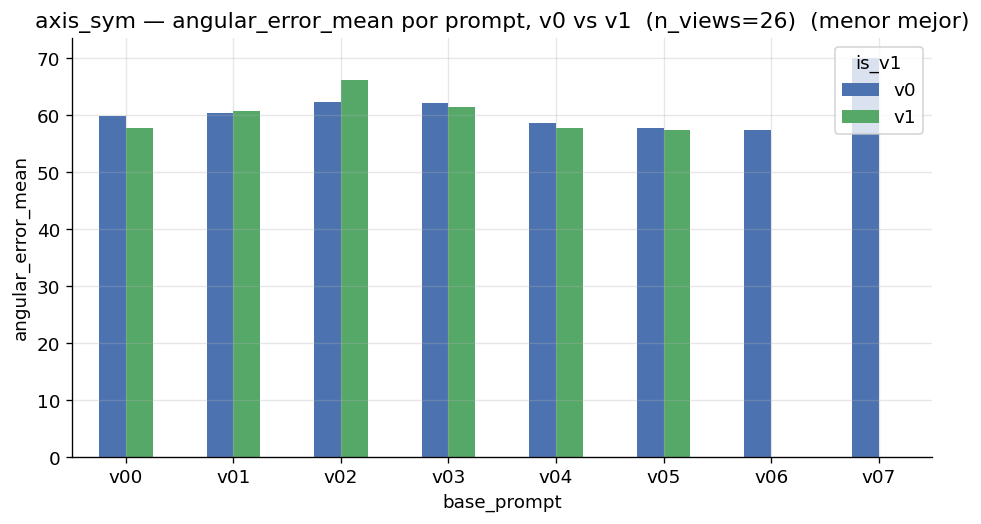

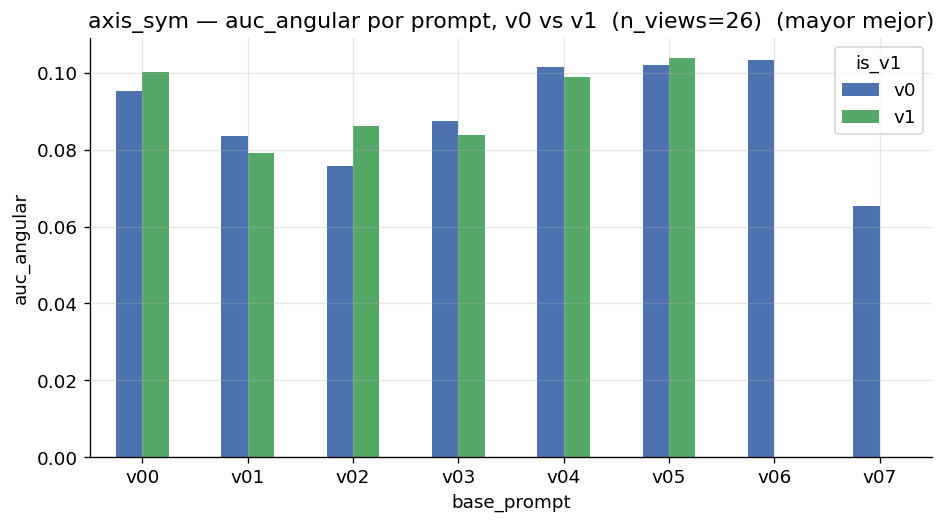

In [27]:
def plot_ablation_bar(df: pd.DataFrame, metric: str, symmetry_label: str,
                      higher_better: bool, n_views: int | None = None) -> None:
    """Barras agrupadas v0 vs v1, una por base_prompt. Si n_views es None usa
    el mayor n_views disponible para cada experimento (via best row already
    filtered by caller) -- pasar un df ya filtrado a un n_views fijo."""
    sub = df[df["flow"].isna()].copy()  # excluye flowB/flowC de esta comparacion
    if n_views is not None:
        sub = sub[sub["n_views"] == n_views]
    piv = sub.pivot_table(index="base_prompt", columns="is_v1", values=metric)
    piv = piv.rename(columns={False: "v0", True: "v1"}).sort_index()

    ax = piv.plot(kind="bar", figsize=(8, 4.5), color=["#4C72B0", "#55A868"])
    ax.set_ylabel(metric)
    direction = "mayor mejor" if higher_better else "menor mejor"
    title_nv = f"  (n_views={n_views})" if n_views is not None else ""
    ax.set_title(f"{symmetry_label} — {metric} por prompt, v0 vs v1{title_nv}  ({direction})")
    ax.grid(axis="y", alpha=0.3)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


NV_AXIS = sorted(df_axis["n_views"].unique())[-1]  # el mas grande disponible
plot_ablation_bar(df_axis, "angular_error_mean", "axis_sym", higher_better=False, n_views=NV_AXIS)
if "auc_angular" in df_axis.columns:
    plot_ablation_bar(df_axis, "auc_angular", "axis_sym", higher_better=True, n_views=NV_AXIS)

### 3.3 Metricas vs n_views, una linea por experimento (eje)

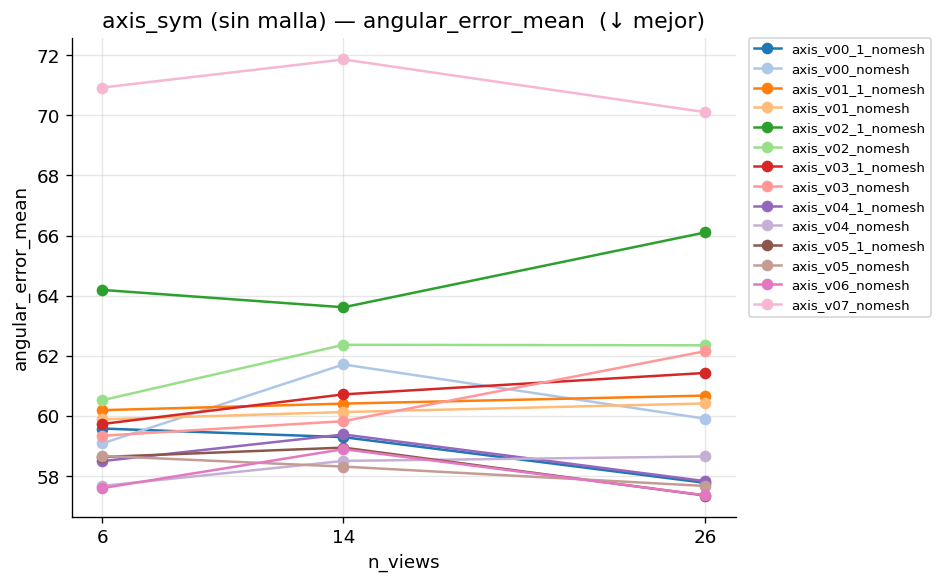

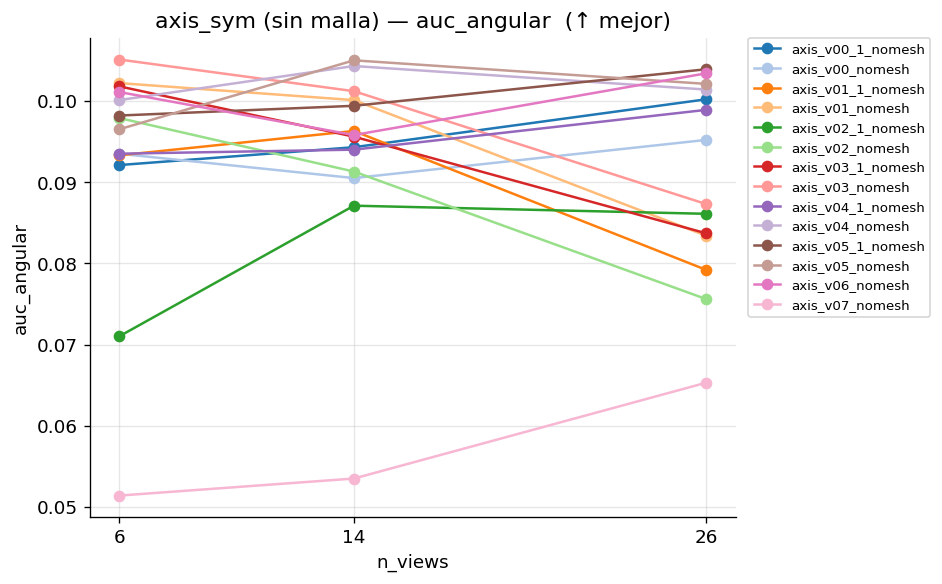

In [28]:
def plot_metric_vs_nviews(df: pd.DataFrame, metric: str, symmetry_label: str,
                          higher_better: bool) -> None:
    if metric not in df.columns:
        print(f"[skip] columna '{metric}' no existe")
        return
    exps   = sorted(df["experiment"].unique())
    cmap   = plt.get_cmap("tab20")
    colors = {e: cmap(i % 20) for i, e in enumerate(exps)}

    fig, ax = plt.subplots(figsize=(8, 5))
    for exp in exps:
        sub = df[df["experiment"] == exp].sort_values("n_views")
        if sub[metric].isna().all():
            continue
        ax.plot(sub["n_views"], sub[metric], marker="o", label=exp, color=colors[exp])
    ax.set_xlabel("n_views")
    ax.set_xticks(sorted(df["n_views"].unique()))
    ax.set_ylabel(metric)
    direction = "↑ mejor" if higher_better else "↓ mejor"
    ax.set_title(f"{symmetry_label} (sin malla) — {metric}  ({direction})")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0, fontsize=8)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_metric_vs_nviews(df_axis, "angular_error_mean", "axis_sym", higher_better=False)
plot_metric_vs_nviews(df_axis, "auc_angular", "axis_sym", higher_better=True)

## 4. Ranking -- plano (`recall_planes_mean` / `f1_ref` descendente = mejor)

Distinto criterio que el eje: no hay `angular_error` de un unico plano, sino
recall/precision sobre el conjunto de planos GT (metodo `triangulation_multiplane`).
Ver `Mapping/evaluate.py::evaluate_plane_multiset`.

In [29]:
PLANE_COLS = ["experiment", "base_prompt", "is_v1", "flow", "n_views", "n_objects",
              "n_planes_predicted_mean", "n_true_planes_mean", "n_planes_matched_mean",
              "recall_planes_mean", "precision_planes_mean", "f1_ref", "f1_ref_hungarian"]
PLANE_COLS = [c for c in PLANE_COLS if c in df_plane.columns]

print("Ranking por experimento (mejor n_views de cada uno), ordenado por recall_planes_mean:")
_plane_ranking = best_per_experiment(df_plane, "recall_planes_mean", ascending=False, cols=PLANE_COLS)
_plane_ranking

Ranking por experimento (mejor n_views de cada uno), ordenado por recall_planes_mean:


,experiment,base_prompt,is_v1,flow,n_views,n_objects,n_planes_predicted_mean,n_true_planes_mean,n_planes_matched_mean,recall_planes_mean,precision_planes_mean,f1_ref,f1_ref_hungarian
0,plane_v07_nomesh,v07,False,None,26,709,2.4866,1.1904,0.9845,0.8578,0.4431,0.1636,0.1763
1,plane_v04_1_nomesh,v04,True,None,14,553,1.8915,1.1682,0.9313,0.8544,0.5181,0.4819,0.4350
2,plane_v04_nomesh,v04,False,None,14,641,1.9423,1.1732,0.9236,0.8445,0.4875,0.4755,0.4256
3,plane_v06_nomesh,v06,False,None,14,531,1.9266,1.1789,0.9077,0.8299,0.4868,0.4348,0.4030
4,plane_v02_nomesh,v02,False,None,14,658,1.9316,1.1809,0.8982,0.8209,0.4764,0.4280,0.4011
5,plane_v00_1_nomesh,v00,True,None,14,582,1.9416,1.1959,0.9021,0.8159,0.4768,0.4424,0.4157
6,plane_v02_1_nomesh,v02,True,None,14,544,1.9467,1.1912,0.8879,0.8076,0.4669,0.4137,0.3881
7,plane_v05_1_nomesh,v05,True,None,14,684,1.9678,1.1827,0.7383,0.6786,0.3801,0.3241,0.3135
8,plane_v00_nomesh,v00,False,None,14,777,1.9704,1.1853,0.6873,0.6347,0.3514,0.2809,0.2773
9,plane_v05_nomesh,v05,False,None,6,839,1.0000,1.1847,0.1979,0.1530,0.1979,0.0787,0.0821


In [30]:
_winner = _plane_ranking.iloc[0]
print(f"GANADOR plano (por recall): {_winner['experiment']}  (n_views={_winner['n_views']}, "
      f"recall={_winner['recall_planes_mean']:.4f}, precision={_winner['precision_planes_mean']:.4f}, "
      f"f1_ref={_winner['f1_ref']:.4f})")
print(f"Peor:                        {_plane_ranking.iloc[-1]['experiment']}  "
      f"(recall={_plane_ranking.iloc[-1]['recall_planes_mean']:.4f}, "
      f"f1_ref={_plane_ranking.iloc[-1]['f1_ref']:.4f})")

# Ranking alternativo ordenado por f1_ref (combina recall+precision) -- no siempre
# coincide con el orden por recall_planes_mean solo.
print("\nRanking alternativo por f1_ref (mejor n_views de cada uno):")
best_per_experiment(df_plane, "f1_ref", ascending=False, cols=PLANE_COLS)

GANADOR plano (por recall): plane_v07_nomesh  (n_views=26, recall=0.8578, precision=0.4431, f1_ref=0.1636)
Peor:                        plane_v01_1_nomesh  (recall=0.0726, f1_ref=0.0722)

Ranking alternativo por f1_ref (mejor n_views de cada uno):


,experiment,base_prompt,is_v1,flow,n_views,n_objects,n_planes_predicted_mean,n_true_planes_mean,n_planes_matched_mean,recall_planes_mean,precision_planes_mean,f1_ref,f1_ref_hungarian
0,plane_v04_1_nomesh,v04,True,None,14,553,1.8915,1.1682,0.9313,0.8544,0.5181,0.4819,0.4350
1,plane_v04_nomesh,v04,False,None,14,641,1.9423,1.1732,0.9236,0.8445,0.4875,0.4755,0.4256
2,plane_v07_nomesh,v07,False,None,14,501,1.9182,1.1737,0.9222,0.8463,0.4990,0.4646,0.4300
3,plane_v00_1_nomesh,v00,True,None,14,582,1.9416,1.1959,0.9021,0.8159,0.4768,0.4424,0.4157
4,plane_v06_nomesh,v06,False,None,14,531,1.9266,1.1789,0.9077,0.8299,0.4868,0.4348,0.4030
5,plane_v02_nomesh,v02,False,None,14,658,1.9316,1.1809,0.8982,0.8209,0.4764,0.4280,0.4011
6,plane_v02_1_nomesh,v02,True,None,14,544,1.9467,1.1912,0.8879,0.8076,0.4669,0.4137,0.3881
7,plane_v05_1_nomesh,v05,True,None,14,684,1.9678,1.1827,0.7383,0.6786,0.3801,0.3241,0.3135
8,plane_v00_nomesh,v00,False,None,14,777,1.9704,1.1853,0.6873,0.6347,0.3514,0.2809,0.2773
9,plane_v03_nomesh,v03,False,None,6,843,1.0000,1.1945,0.1732,0.1089,0.1732,0.0829,0.0862


### 4.1 Tabla completa (todos los n_views) -- plano

In [31]:
grad_cols = [c for c in ["recall_planes_mean", "precision_planes_mean", "f1_ref"] if c in PLANE_COLS]
(df_plane[PLANE_COLS]
   .sort_values(["experiment", "n_views"])
   .style.background_gradient(subset=grad_cols, cmap="RdYlGn"))

,experiment,base_prompt,is_v1,flow,n_views,n_objects,n_planes_predicted_mean,n_true_planes_mean,n_planes_matched_mean,recall_planes_mean,precision_planes_mean,f1_ref,f1_ref_hungarian
41,plane_v00_1_nomesh,v00,True,None,6,737,1.000000,1.180500,0.316100,0.293300,0.316100,0.148300,0.160500
17,plane_v00_1_nomesh,v00,True,None,14,582,1.941600,1.195900,0.902100,0.815900,0.476800,0.442400,0.415700
16,plane_v00_1_nomesh,v00,True,None,26,837,2.359600,1.192400,0.875700,0.763000,0.424100,0.171100,0.184200
15,plane_v00_nomesh,v00,False,None,6,833,1.000000,1.194500,0.411800,0.368100,0.411800,0.144000,0.156700
14,plane_v00_nomesh,v00,False,None,14,777,1.970400,1.185300,0.687300,0.634700,0.351400,0.280900,0.277300
13,plane_v00_nomesh,v00,False,None,26,810,2.350600,1.195100,0.675300,0.595100,0.331100,0.133000,0.144200
12,plane_v01_1_nomesh,v01,True,None,6,847,1.000000,1.193600,0.125100,0.072600,0.125100,0.072200,0.071000
11,plane_v01_1_nomesh,v01,True,None,14,847,1.958700,1.191300,0.022400,0.016300,0.011200,0.001300,0.001500
10,plane_v01_1_nomesh,v01,True,None,26,844,2.001200,1.194300,0.016600,0.012200,0.008300,0.000500,0.000600
18,plane_v01_nomesh,v01,False,None,6,846,1.000000,1.193900,0.127700,0.077400,0.127700,0.067100,0.067900


### 4.2 Ablation: v0 vs v1 (plano)

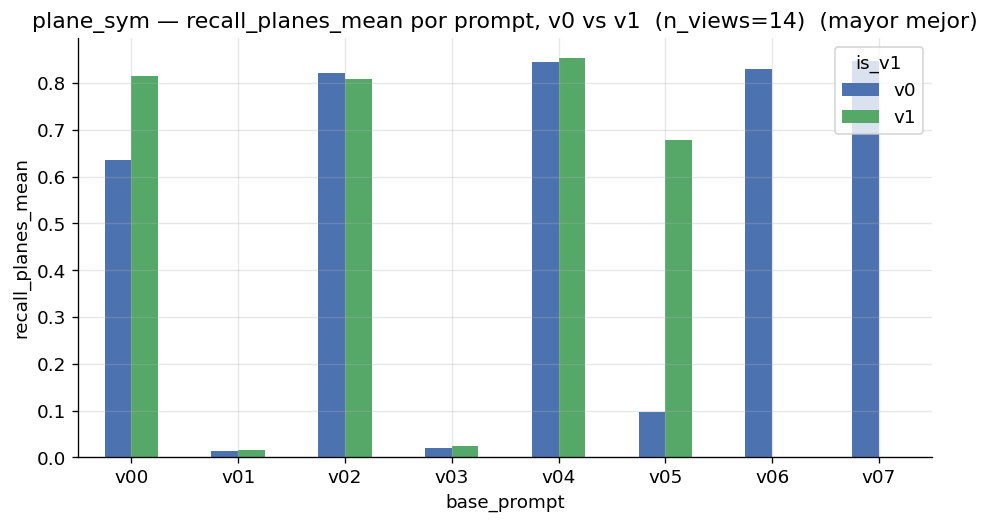

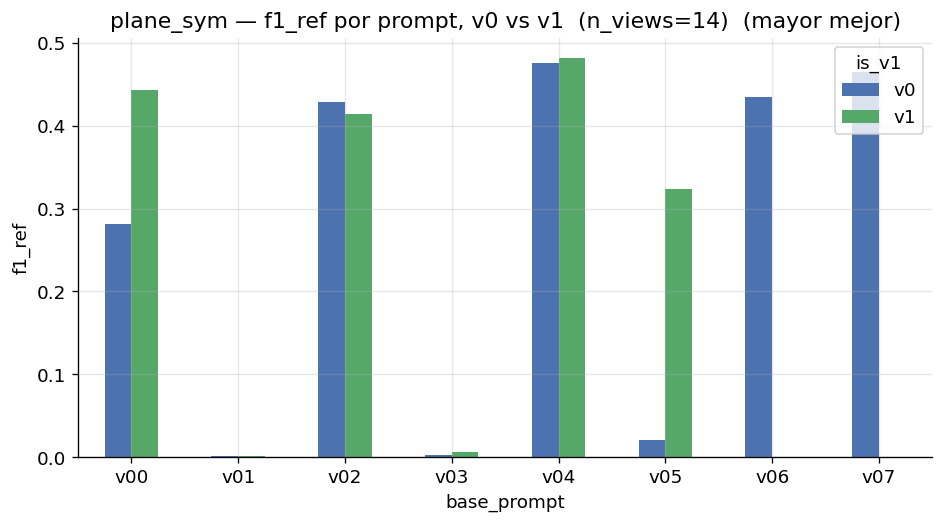

In [32]:
NV_PLANE = 14  # n_views=14 fue el optimo empirico observado, no el maximo
if NV_PLANE not in df_plane["n_views"].unique():
    NV_PLANE = sorted(df_plane["n_views"].unique())[-1]

plot_ablation_bar(df_plane, "recall_planes_mean", "plane_sym", higher_better=True, n_views=NV_PLANE)
if "f1_ref" in df_plane.columns:
    plot_ablation_bar(df_plane, "f1_ref", "plane_sym", higher_better=True, n_views=NV_PLANE)

### 4.3 Metricas vs n_views, una linea por experimento (plano)

Ojo: a diferencia del eje, mas vistas NO siempre mejora recall/precision en el
flujo sin malla (el metodo multi-plano puede sobre-segmentar con muchas vistas) --
esta es la seccion para confirmarlo/refutarlo con cada tanda nueva de prompts.

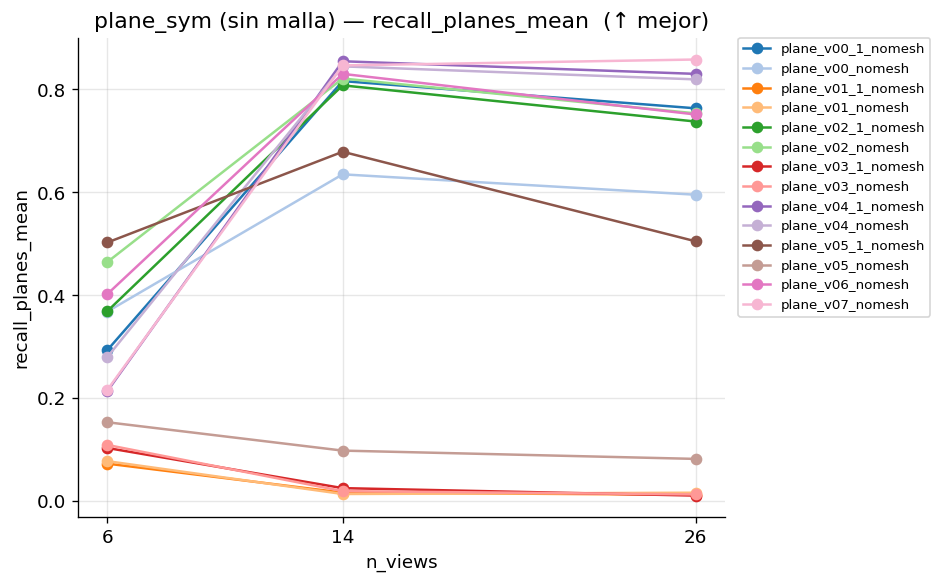

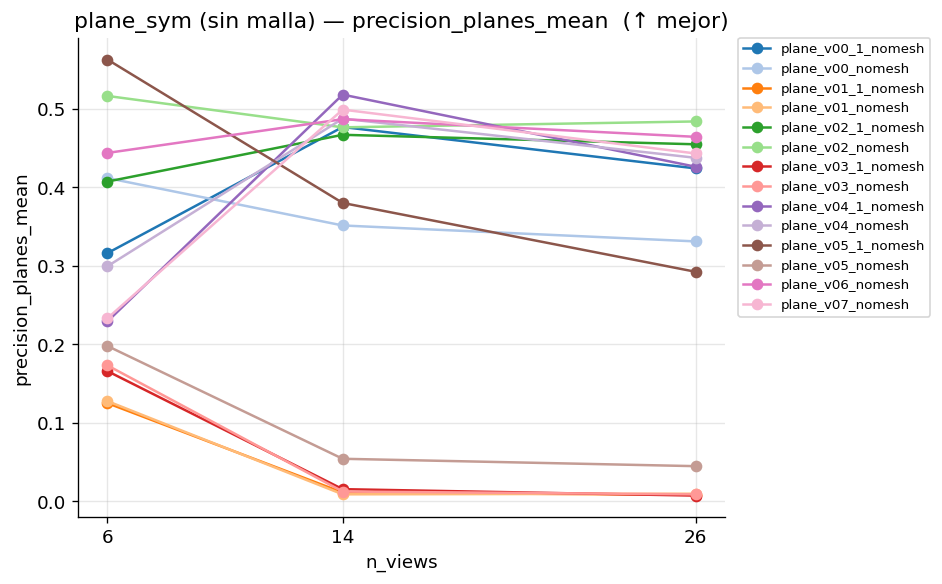

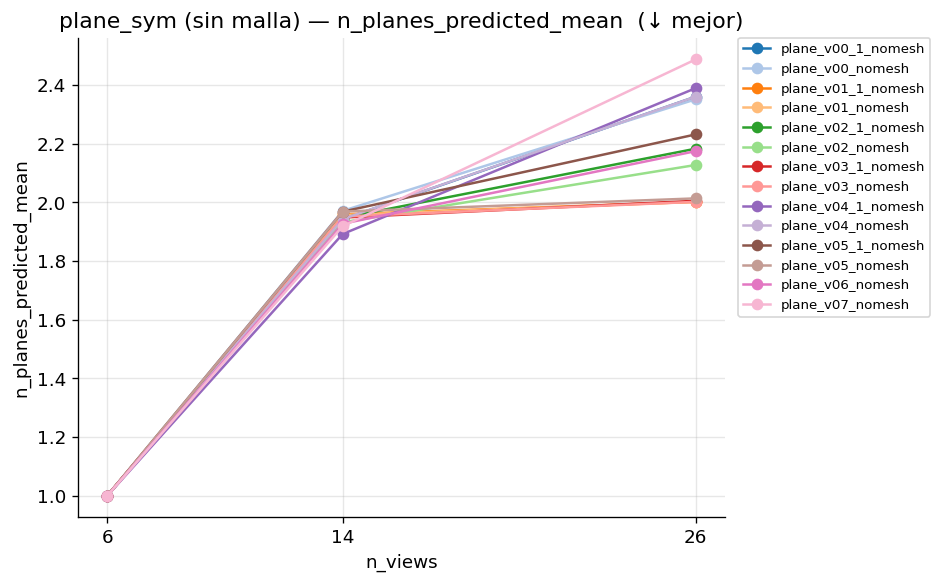

In [33]:
plot_metric_vs_nviews(df_plane, "recall_planes_mean", "plane_sym", higher_better=True)
plot_metric_vs_nviews(df_plane, "precision_planes_mean", "plane_sym", higher_better=True)
plot_metric_vs_nviews(df_plane, "n_planes_predicted_mean", "plane_sym", higher_better=None)

## 5. Filtrar a un subconjunto de prompts nuevos

Cuando agregues una tanda nueva de prompts y quieras comparar SOLO esos (sin el
ruido visual de todos los anteriores), filtra por `experiment` antes de graficar.

,experiment,base_prompt,is_v1,flow,method,n_views,n_total,n_objects,angular_error_mean,angular_error_median,angular_error_std,translation_error_mean,translation_error_median,translation_error_std,translation_error_normalized_mean,translation_error_normalized_median,auc_angular,n_points_mean,precision_5deg,precision_10deg,precision_15deg,sde_ref_mean,sde_ref_min,sde_ref_max
26,axis_v06_nomesh,v06,False,None,triangulation,6,850,824,57.6047,59.6248,22.1268,0.355892,0.035175,1.303489,0.335807,0.032334,0.1011,5.92,0.0071,0.0153,0.0471,0.043128,0.000160,1.871801
25,axis_v06_nomesh,v06,False,None,triangulation,14,850,812,58.9004,61.6038,22.2484,0.191992,0.033539,0.609009,0.180273,0.030526,0.0958,13.82,0.0047,0.0188,0.0447,0.044493,0.000190,0.797188
24,axis_v06_nomesh,v06,False,None,triangulation,26,850,821,57.3673,58.6836,22.3965,0.176784,0.064009,0.347021,0.165033,0.059770,0.1034,25.62,0.0035,0.0176,0.0435,0.060857,0.000178,1.535466
23,axis_v07_nomesh,v07,False,None,triangulation,6,850,502,70.9215,79.6162,22.3367,0.804577,0.079771,3.067103,0.738874,0.070027,0.0514,5.83,0.0024,0.0094,0.0141,0.049924,0.000033,0.916781
22,axis_v07_nomesh,v07,False,None,triangulation,14,850,493,71.8560,82.7378,22.3883,0.293738,0.038356,0.667895,0.273695,0.033819,0.0535,13.75,0.0024,0.0094,0.0188,0.045993,0.000013,0.329988
9,axis_v07_nomesh,v07,False,None,triangulation,26,850,500,70.1031,80.6962,23.5694,0.236471,0.056262,0.411709,0.219865,0.051823,0.0653,25.71,0.0012,0.0082,0.0235,0.065045,0.000013,1.211637


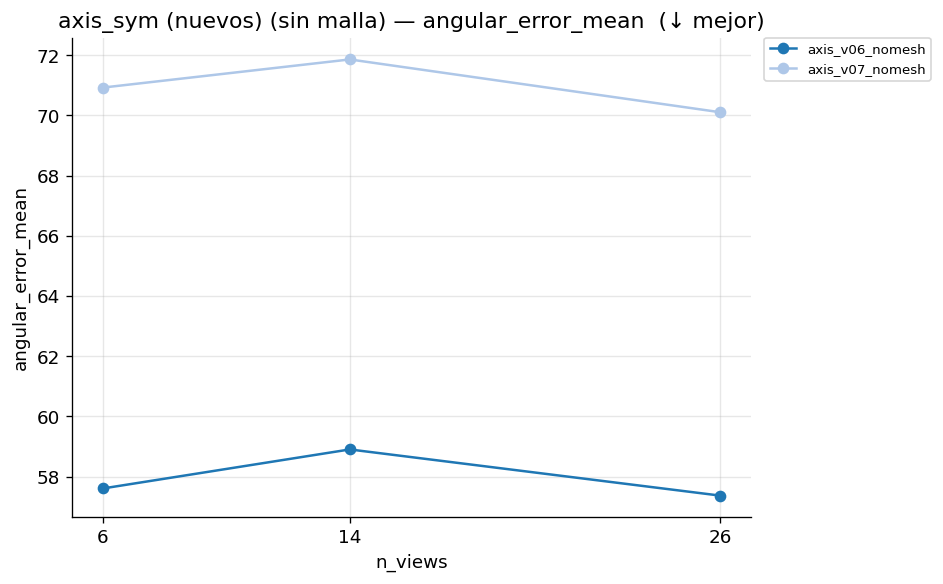

,experiment,base_prompt,is_v1,flow,n_views,n_objects,n_planes_predicted_mean,n_true_planes_mean,n_planes_matched_mean,recall_planes_mean,precision_planes_mean,f1_ref,f1_ref_hungarian
26,plane_v06_nomesh,v06,False,None,6,730,1.0000,1.1836,0.4438,0.4021,0.4438,0.2179,0.2362
25,plane_v06_nomesh,v06,False,None,14,531,1.9266,1.1789,0.9077,0.8299,0.4868,0.4348,0.4030
24,plane_v06_nomesh,v06,False,None,26,822,2.1740,1.1898,0.8650,0.7510,0.4643,0.2046,0.2228
23,plane_v07_nomesh,v07,False,None,6,652,1.0000,1.1702,0.2331,0.2160,0.2331,0.1121,0.1208
22,plane_v07_nomesh,v07,False,None,14,501,1.9182,1.1737,0.9222,0.8463,0.4990,0.4646,0.4300
9,plane_v07_nomesh,v07,False,None,26,709,2.4866,1.1904,0.9845,0.8578,0.4431,0.1636,0.1763


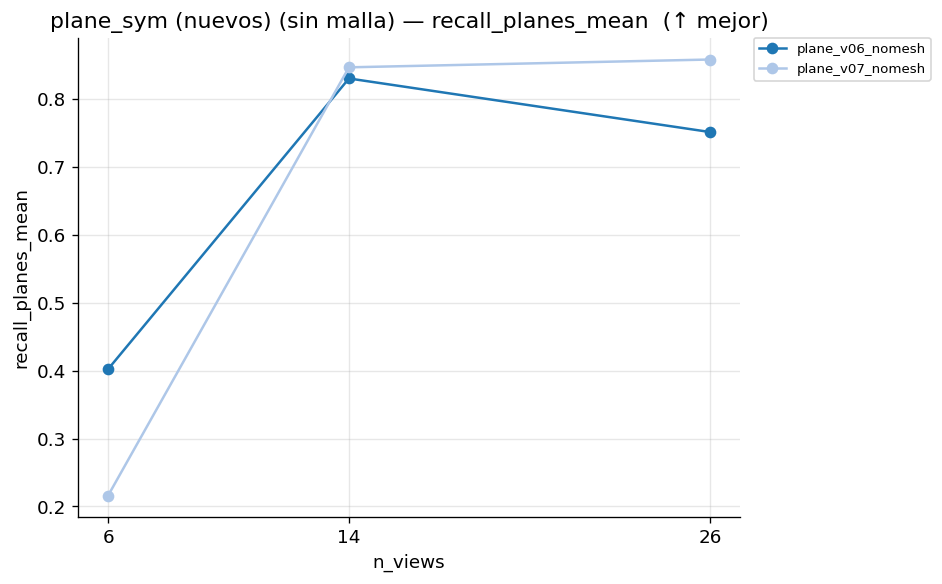

In [34]:
NUEVOS_AXIS  = ["axis_v06_nomesh", "axis_v07_nomesh"]
NUEVOS_PLANE = ["plane_v06_nomesh", "plane_v07_nomesh"]

if NUEVOS_AXIS:
    sub = df_axis[df_axis["experiment"].isin(NUEVOS_AXIS)]
    display(sub[AXIS_COLS].sort_values(["experiment", "n_views"]))
    plot_metric_vs_nviews(sub, "angular_error_mean", "axis_sym (nuevos)", higher_better=False)

if NUEVOS_PLANE:
    sub = df_plane[df_plane["experiment"].isin(NUEVOS_PLANE)]
    display(sub[PLANE_COLS].sort_values(["experiment", "n_views"]))
    plot_metric_vs_nviews(sub, "recall_planes_mean", "plane_sym (nuevos)", higher_better=True)

## 6. Exportar ranking final

In [35]:
out_dir = RESULTS_ROOT / f"experiments_{date.today().strftime('%d_%m_%Y')}"
out_dir.mkdir(parents=True, exist_ok=True)

best_per_experiment(df_axis, "angular_error_mean", ascending=True, cols=AXIS_COLS) \
    .to_csv(out_dir / "axis_sym_nomesh_ranking.csv", index=False)
best_per_experiment(df_plane, "recall_planes_mean", ascending=False, cols=PLANE_COLS) \
    .to_csv(out_dir / "plane_sym_nomesh_ranking.csv", index=False)

print(f"Guardado en: {out_dir}")

Guardado en: C:\Users\HP\Desktop\Seminario de Tesis I\Symmetry-Detection-Using-Multimodal-Vision-Language-Models\results\experiments_27_08_2026


## 7. Comparacion antes/despues del filtro fondo/objeto (`--filter-off-object`)

Esta seccion es DISTINTA de la 1-6: ahi cada prompt tiene su propio
`experiment_id` y concatenar+deduplicar tiene sentido. Aca el filtro se
corrio **sobreescribiendo el mismo `experiment_id`** (`axis_v06_nomesh`,
`plane_v04_1_nomesh`) en vez de usar un id nuevo con sufijo `_filtered` --
valido, pero significa que "antes" y "despues" viven en dos CARPETAS
`experiments_*` distintas con el MISMO `experiment_id` adentro, no en dos
filas con distinto id. Si los concatenaramos como en la seccion 1, el
`drop_duplicates(keep="last")` se quedaria solo con uno de los dos y
perderiamos la comparacion -- por eso aca se cargan por separado y se hace
un merge explicito, no la carga generica de la seccion 1.

Carpetas usadas (ajustar si tus rutas son otras):
- **Antes** (sin filtro): `results/experiments_27_08_2026`
- **Despues** (con `--filter-off-object`): `results/experiments_27_08_2026_v2`

In [36]:
ANTES_DIR   = RESULTS_ROOT / "experiments_27_08_2026"
DESPUES_DIR = RESULTS_ROOT / "experiments_27_08_2026_v2"


def load_before_after(symmetry_type: str) -> pd.DataFrame:
    antes   = pd.read_csv(ANTES_DIR / f"{symmetry_type}_nomesh_comparison.csv")
    despues = pd.read_csv(DESPUES_DIR / f"{symmetry_type}_nomesh_comparison.csv")
    antes["variante"]   = "sin_filtro"
    despues["variante"] = "con_filtro"
    return pd.concat([antes, despues], ignore_index=True)


def diff_table(df_both: pd.DataFrame, metrics: list[str], higher_better: dict[str, bool]) -> pd.DataFrame:
    """Un merge explicito antes vs despues (NO concatenar+deduplicar, ver
    nota de la seccion 8) -- una fila por experiment x n_views, con columnas
    _antes / _despues / delta por cada metrica pedida."""
    antes   = df_both[df_both["variante"] == "sin_filtro"]
    despues = df_both[df_both["variante"] == "con_filtro"]
    m = pd.merge(antes, despues, on=["experiment", "method", "n_views"],
                suffixes=("_antes", "_despues"))

    out = m[["experiment", "method", "n_views"]].copy()
    for metric in metrics:
        out[f"{metric}_antes"]   = m[f"{metric}_antes"]
        out[f"{metric}_despues"] = m[f"{metric}_despues"]
        delta = m[f"{metric}_despues"] - m[f"{metric}_antes"]
        out[f"{metric}_delta"] = delta.round(4)
        # con higher_better=False (ej. angular_error), delta negativo = mejora
        sign = 1 if higher_better.get(metric, True) else -1
        out[f"{metric}_mejoro"] = (sign * delta) > 0

    # solo interesan las filas donde ALGO cambio -- todo lo demas son prompts
    # que no se tocaron con --filter-off-object (deltas exactamente 0)
    any_delta_cols = [f"{m_}_delta" for m_ in metrics]
    changed = out[(out[any_delta_cols].abs() > 1e-9).any(axis=1)]
    return changed.sort_values(["experiment", "n_views"]).reset_index(drop=True)

### 7.1 Eje -- `axis_v06_nomesh` con vs. sin filtro

In [37]:
axis_both = load_before_after("axis_sym")

axis_metrics_higher_better = {
    "angular_error_mean": False, "angular_error_median": False, "angular_error_std": False,
    "translation_error_mean": False, "translation_error_median": False, "translation_error_std": False,
    "auc_angular": True, "precision_5deg": True, "precision_10deg": True, "precision_15deg": True,
    "n_objects": True,
}
axis_diff = diff_table(
    axis_both,
    metrics=[c for c in axis_metrics_higher_better if c in axis_both.columns],
    higher_better=axis_metrics_higher_better,
)

if axis_diff.empty:
    print("[info] Ningun experimento de eje cambio entre ANTES_DIR y DESPUES_DIR "
          "-- revisa las rutas o si el filtro realmente corrio con --overwrite.")
else:
    print(f"{axis_diff['experiment'].nunique()} experimento(s) de eje cambiaron con el filtro:")
    display(axis_diff[["experiment", "n_views",
                        "angular_error_mean_antes", "angular_error_mean_despues", "angular_error_mean_delta",
                        "translation_error_mean_antes", "translation_error_mean_despues", "translation_error_mean_delta",
                        "translation_error_std_antes", "translation_error_std_despues", "translation_error_std_delta",
                        "n_objects_antes", "n_objects_despues", "n_objects_delta"]])

[info] Ningun experimento de eje cambio entre ANTES_DIR y DESPUES_DIR -- revisa las rutas o si el filtro realmente corrio con --overwrite.


### 7.2 Plano -- `plane_v04_1_nomesh` con vs. sin filtro

In [38]:
plane_both = load_before_after("plane_sym")

plane_metrics_higher_better = {
    "recall_planes_mean": True, "precision_planes_mean": True,
    "n_planes_matched_mean": True, "n_planes_predicted_mean": None,
    "f1_ref": True, "f1_ref_hungarian": True, "n_objects": True,
}
plane_diff = diff_table(
    plane_both,
    metrics=[c for c in plane_metrics_higher_better if c in plane_both.columns and plane_metrics_higher_better[c] is not None],
    higher_better={k: v for k, v in plane_metrics_higher_better.items() if v is not None},
)

if plane_diff.empty:
    print("[info] Ningun experimento de plano cambio entre ANTES_DIR y DESPUES_DIR "
          "-- revisa las rutas o si el filtro realmente corrio con --overwrite.")
else:
    print(f"{plane_diff['experiment'].nunique()} experimento(s) de plano cambiaron con el filtro:")
    display(plane_diff[["experiment", "n_views",
                         "recall_planes_mean_antes", "recall_planes_mean_despues", "recall_planes_mean_delta",
                         "precision_planes_mean_antes", "precision_planes_mean_despues", "precision_planes_mean_delta",
                         "f1_ref_antes", "f1_ref_despues", "f1_ref_delta",
                         "n_objects_antes", "n_objects_despues", "n_objects_delta"]])

[info] Ningun experimento de plano cambio entre ANTES_DIR y DESPUES_DIR -- revisa las rutas o si el filtro realmente corrio con --overwrite.
